# Wind Speed Forecasting Benchmark Replication — GA vs. PSO vs. CCO vs. Published Literature

**Purpose.** Your original project (IEA monthly renewable energy, 193 points/series) showed CCO dominating the
23-function benchmark suite but *not* winning on the applied task, with no statistically significant difference
between GA/PSO/CCO. This notebook tests a sharper, more direct claim: on a **public dataset that other papers
have already published GA and PSO baselines for**, does your CCO implementation beat those published numbers?

**Target paper and dataset.**
Khodairy et al., *"Wind speed forecasting using optimized bidirectional LSTM based on dipper throated and
genetic optimization algorithms,"* Frontiers in Energy Research, 2023.
Dataset: Kaggle ["Wind Speed Prediction Dataset"](https://www.kaggle.com/datasets/fedesoriano/wind-speed-prediction-dataset)
— 6,574 daily weather-station observations, 1961–1978, predicting daily average wind speed (`WIND`).

**Published numbers to beat (their Table, RMSE):**

| Model | RMSE |
|---|---|
| Baseline BiLSTM (no tuning) | 0.012 |
| PSO-BiLSTM | 0.00089 |
| GA-BiLSTM | 0.00072 |
| DTO-BiLSTM | 0.00068 |
| Their hybrid GADTO-BiLSTM | 0.00046 |

**Important honesty check before you trust any "we beat them" claim.** I read the full methods section of that
paper and it does **not** specify: the look-back window length, exact BiLSTM layer/unit count, number of training
epochs, the optimizer used to train the network weights, or whether RMSE is computed on the min-max-scaled [0,1]
target or original knots. It *does* specify: min-max scaling to [0,1], a chronological 70%/10%/20% train/val/test
split, and the GA/PSO population and iteration budget (10 agents, 80 iterations each). Because of those gaps,
this cannot be a bit-exact reproduction — no one reading only the published paper could reproduce it exactly.
What we *can* do, and what is standard practice when a paper under-specifies its methods, is: match everything
they did specify (scaling, split, GA/PSO budget), make our own architecture/lookback choices explicit and
reasonable, and report results on **both** the [0,1]-scaled target (directly comparable to their numbers, since
0.012–0.00046 is far too small to be plausible on raw knots) **and** back-transformed original units (for your
own sanity check). Treat the comparison as "same dataset, same preprocessing protocol, comparable budget" rather
than "identical experiment" — and say so explicitly in your paper. That's more defensible than an unqualified
"we beat them," and reviewers respect it more.

**How to use this notebook.**
1. Download `wind_dataset.csv` from the Kaggle link above (Kaggle isn't reachable from my sandbox, so you'll need
   to do this step) and upload it when Cell 3 asks.
2. Run Cells 1–2 as-is.
3. **Cell 4 needs your original notebook's helper/algorithm code pasted in** — `OptimizerResult`, `apply_bounds`,
   `levy_flight`, `genetic_algorithm`, `particle_swarm_optimization`, `cuckoo_catfish_optimizer`, and the
   `OPTIMIZERS` registry — copied unchanged from `EC_Project_Code.ipynb` (your Cells 6–10). I deliberately did not
   retype your ~200-line CCO implementation from memory here; copying your own validated code is safer than me
   reconstructing it and risking a transcription bug that would invalidate the whole comparison.
4. Everything else (data loading, multivariate BiLSTM, search space, training loop, literature comparison table)
   is new and ready to run.
5. Cell 3's loader prints the detected columns before doing anything else — if the auto-detected target column
   looks wrong, fix the one `TARGET_COL` line it points you to.


## Cell 1: Install dependencies

In [1]:
import sys, subprocess, importlib.util, shutil


def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


# --- Core dependencies (CPU-only wheels are fine for these) ---
required_packages = ["numpy", "pandas", "matplotlib", "sklearn", "scipy"]
package_map = {"sklearn": "scikit-learn"}
missing = [package_map.get(p, p) for p in required_packages
           if importlib.util.find_spec(p) is None]
if missing:
    pip_install(*missing)

# --- PyTorch: install a CUDA build if an NVIDIA GPU is present, otherwise the CPU build ---
# Pick the channel that matches your installed NVIDIA driver (newer drivers are backward
# compatible, so when unsure use the latest): cu121 / cu124 / cu128 ...
# Reference: https://pytorch.org/get-started/locally/
CUDA_CHANNEL = "cu124"

has_nvidia_gpu = shutil.which("nvidia-smi") is not None


def torch_cuda_ok():
    try:
        import torch
        return torch.cuda.is_available()
    except ImportError:
        return False


if torch_cuda_ok():
    print("PyTorch with CUDA already installed -- nothing to do.")
elif has_nvidia_gpu:
    print(f"NVIDIA GPU detected -- installing the CUDA ({CUDA_CHANNEL}) build of PyTorch...")
    pip_install("torch", "--index-url", f"https://download.pytorch.org/whl/{CUDA_CHANNEL}",
                "--force-reinstall")
    print("NOTE: if PyTorch was already imported in this kernel, restart the kernel now "
          "(Kernel > Restart) so the CUDA build takes effect, then re-run from Cell 1.")
elif importlib.util.find_spec("torch") is None:
    print("No NVIDIA GPU detected -- installing the CPU build of PyTorch...")
    pip_install("torch")

# --- Report what we ended up with ---
try:
    import torch
    line = f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}"
    if torch.cuda.is_available():
        line += f" | {torch.cuda.get_device_name(0)}"
    print(line)
except ImportError:
    print("PyTorch is not installed.")

print("Dependencies OK.")

PyTorch with CUDA already installed -- nothing to do.
PyTorch 2.6.0+cu124 | CUDA available: True | NVIDIA GeForce RTX 4060
Dependencies OK.


## Cell 2: Imports, configuration, reproducibility

In [2]:
from pathlib import Path
import os, math, time, random, warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

warnings.filterwarnings("ignore")

SEED = 42

# --- ASSUMPTION (source paper does not specify this): look-back window in days.
# The source paper never states its sequence length. Daily-average wind speed has short
# memory (lag-1 autocorrelation ~0.59, decaying toward 0 within a week), so a 7-day window
# keeps the informative recent lags without diluting the LSTM's capacity on near-noise
# steps 8-14. Treat this as a hyperparameter worth sweeping (try 3, 5, 7, 10, 14), not a
# fact taken from the paper.
LOOKBACK = 7

# Budget matched to the source paper's Table 2 (GA: 10 agents x 80 iters; PSO: 10 particles x 80 iters).
# CCO uses the SAME budget for a fair three-way comparison. This is deliberately smaller than your
# original "paper" profile's iteration count for the energy task, but matches what the literature
# baseline you are targeting actually used.
LITERATURE_MATCH_PROFILE = {
    "agents": 10,
    "iterations": 80,
    "fitness_epochs": 30,   # not specified by the source paper -- your own reasonable choice, document it
    "final_epochs": 150,    # not specified by the source paper -- your own reasonable choice, document it
    "seed_runs": 3,
}

# Quick end-to-end sanity check. This is NOT a reportable result -- it only proves the whole
# pipeline (optimizers -> decode -> train -> compare) runs without error, in a couple of minutes,
# before you commit GPU time to the full literature-matched run above.
SMOKE_TEST_PROFILE = {
    "agents": 4,
    "iterations": 10,
    "fitness_epochs": 8,
    "final_epochs": 30,
    "seed_runs": 1,
}

# Flip to "full" once the smoke test passes.
RUN_MODE = "full"   # "smoke" -> SMOKE_TEST_PROFILE  |  "full" -> LITERATURE_MATCH_PROFILE
ACTIVE_PROFILE = {"smoke": SMOKE_TEST_PROFILE, "full": LITERATURE_MATCH_PROFILE}[RUN_MODE]
print(f"RUN_MODE = {RUN_MODE!r}  ->  profile: {ACTIVE_PROFILE}")
if RUN_MODE == "smoke":
    print("  (smoke test -- results are NOT reportable; set RUN_MODE='full' for the real run)")

# Published literature numbers this notebook will compare against (RMSE, scaled [0,1] target).
LITERATURE_RESULTS = {
    "Baseline BiLSTM (no tuning)": 0.012,
    "PSO-BiLSTM (Khodairy et al. 2023)": 0.00089,
    "GA-BiLSTM (Khodairy et al. 2023)": 0.00072,
    "DTO-BiLSTM (Khodairy et al. 2023)": 0.00068,
    "GADTO-BiLSTM (Khodairy et al. 2023, their proposed hybrid)": 0.00046,
}

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # benchmark=True lets cuDNN pick the fastest kernels for our fixed input shapes
    # (worth it here: every fitness eval trains the same-shaped BiLSTM many times).
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_global_seed(SEED)

# --- Device selection (running locally, not Colab). Prefer an NVIDIA CUDA GPU;
#     fall back to Apple Silicon (MPS), then CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU:     {props.name}")
    print(f"VRAM:    {props.total_memory / 1024**3:.1f} GiB")
    print(f"CUDA (torch build): {torch.version.cuda} | cuDNN: {torch.backends.cudnn.version()}")
    # Allow TF32 on Ampere or newer (RTX 30xx/40xx, A100, ...) -- large matmul/conv speedup,
    # accuracy loss is negligible for this forecasting task.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
elif DEVICE.type == "mps":
    print("Using Apple Silicon GPU via the MPS backend.")
else:
    print("No GPU detected -- this benchmark will be slow on CPU.")
    print("If you have an NVIDIA GPU, install a CUDA build of PyTorch, e.g.:")
    print("    pip uninstall -y torch")
    print("    pip install torch --index-url https://download.pytorch.org/whl/cu124")
    print("then restart the kernel and re-run. Verify with:")
    print('    python -c "import torch; print(torch.cuda.is_available())"')

RESULTS_DIR = Path("results_wind_benchmark")
RESULTS_DIR.mkdir(exist_ok=True)

RUN_MODE = 'full'  ->  profile: {'agents': 10, 'iterations': 80, 'fitness_epochs': 30, 'final_epochs': 150, 'seed_runs': 3}
PyTorch: 2.6.0+cu124
Device:  cuda
GPU:     NVIDIA GeForce RTX 4060
VRAM:    8.0 GiB
CUDA (torch build): 12.4 | cuDNN: 90100


## Cell 3: Load `wind_dataset.csv`

`wind_dataset.csv` lives in the same folder as this notebook (download it from the Kaggle link in the
intro cell if it is missing). The loader auto-detects the date and target columns and **prints what it
found** so you can catch a wrong guess immediately instead of silently training on the wrong column.
Set `DATA_PATH` below if your copy is somewhere else.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# Path to the dataset. Default: next to this notebook. Override if your copy lives elsewhere.
DATA_PATH = Path("wind_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}\n"
        "Download wind_dataset.csv from the Kaggle link in the intro cell and place it next to "
        "this notebook, or set DATA_PATH to its location."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.resolve()}")
print("Raw shape:", df_raw.shape)
print("Raw columns:", list(df_raw.columns))
display(df_raw.head())

# --- Auto-detect the date column (if any) ---
DATE_COL = None
for c in df_raw.columns:
    if c.strip().upper() in {"DATE", "TIME", "TIMESTAMP"}:
        DATE_COL = c
        break

# --- Auto-detect the target column: prefer an exact/near match to "WIND" that is NOT an
#     indicator/flag column (this dataset has IND / IND.1 / IND.2 quality-flag columns
#     alongside the real measurements -- do not target those). ---
candidates = [c for c in df_raw.columns if "wind" in c.strip().lower() and "ind" not in c.strip().lower().replace("wind", "")]
if not candidates:
    candidates = [c for c in df_raw.columns if c.strip().upper() == "WIND"]
TARGET_COL = candidates[0] if candidates else None

print()
print(f"Detected date column:   {DATE_COL!r}")
print(f"Detected target column: {TARGET_COL!r}")
print()
print("!! CHECK THE ABOVE CAREFULLY. If TARGET_COL is wrong or None, set it manually right here:")
# TARGET_COL = "WIND"   # <-- uncomment and fix if the auto-detection above got it wrong

if TARGET_COL is None:
    raise ValueError("Could not auto-detect the target column -- set TARGET_COL manually above and re-run.")

# --- Parse the date and sort chronologically BEFORE building the feature list, so the
#     calendar-derived features added below are picked up as model inputs. ---
if DATE_COL is not None:
    df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors="coerce")
    df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)

    # --- Day-of-year seasonality: explicit annual cycle.
    # This station is windier in winter, calmer in summer. Temperature is only a noisy,
    # phase-shifted proxy for season; encoding the calendar position directly as sin/cos
    # (so Dec 31 -> Jan 1 is continuous, no discontinuity) gives the model a clean seasonal
    # signal and lets the LSTM concentrate on the day-to-day deviations. NO LEAKAGE: the
    # date of the day being forecast is known in advance.
    _doy = df_raw[DATE_COL].dt.dayofyear
    df_raw["DOY_SIN"] = np.sin(2 * np.pi * _doy / 365.25)
    df_raw["DOY_COS"] = np.cos(2 * np.pi * _doy / 365.25)

# Feature columns = every numeric column except the target (indicator/flag columns are kept as
# features on purpose: they carry real information about data quality/provenance).
feature_cols = [c for c in df_raw.columns if c != TARGET_COL and c != DATE_COL
                 and pd.api.types.is_numeric_dtype(df_raw[c])]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Fill any missing values in features/target with forward-fill then a column median (documented, simple choice).
for c in feature_cols + [TARGET_COL]:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
    df_raw[c] = df_raw[c].ffill().fillna(df_raw[c].median())

print()
print(f"Final usable rows: {len(df_raw)}")

Loaded C:\Users\Mega-Pc\Downloads\EC-CCO-Project-main\wind_dataset.csv
Raw shape: (6574, 9)
Raw columns: ['DATE', 'WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN', 'T.MIN.G']


,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
0,1961-01-01,13.67,0,0.2,0.0,9.5,0.0,3.7,-1.0
1,1961-01-02,11.50,0,5.1,0.0,7.2,0.0,4.2,1.1
2,1961-01-03,11.25,0,0.4,0.0,5.5,0.0,0.5,-0.5
3,1961-01-04,8.63,0,0.2,0.0,5.6,0.0,0.4,-3.2
4,1961-01-05,11.92,0,10.4,0.0,7.2,1.0,-1.5,-7.5



Detected date column:   'DATE'
Detected target column: 'WIND'

!! CHECK THE ABOVE CAREFULLY. If TARGET_COL is wrong or None, set it manually right here:
Feature columns (9): ['IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN', 'T.MIN.G', 'DOY_SIN', 'DOY_COS']

Final usable rows: 6574


## Cell 4: Generic optimizer result class and helper functions

In [4]:
@dataclass
class OptimizerResult:
    best_position: np.ndarray
    best_fitness: float
    history: list
    runtime_seconds: float


def apply_bounds(x, low, high, rng=None):
    x = np.asarray(x, dtype=float).copy()
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    if rng is not None and rng.random() < 0.5:
        mask = (x < low) | (x > high)
        if np.any(mask):
            x[mask] = low[mask] + rng.random(np.sum(mask)) * (high[mask] - low[mask])
        return x
    return np.clip(x, low, high)


def levy_flight(dim, rng, beta=1.5, scale=0.05):
    sigma_u = (
        math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
        (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = rng.normal(0, sigma_u, dim)
    v = rng.normal(0, 1, dim)
    return scale * u / (np.abs(v) ** (1 / beta) + 1e-12)

## Cell 5: Genetic Algorithm

In [5]:
def genetic_algorithm(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                      crossover_rate=0.85, mutation_rate=0.15, mutation_scale=0.10,
                      verbose=False):
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])
    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    history = [best_fit]

    def tournament_select():
        k = min(3, pop_size)
        idx = rng.choice(pop_size, size=k, replace=False)
        return pop[idx[np.argmin(fit[idx])]].copy()

    for it in range(1, n_iter + 1):
        new_pop = [best_pos.copy()]
        while len(new_pop) < pop_size:
            p1 = tournament_select()
            p2 = tournament_select()
            if rng.random() < crossover_rate:
                alpha = rng.random(dim)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()

            for child in [c1, c2]:
                mutation_mask = rng.random(dim) < mutation_rate
                noise = rng.normal(0, mutation_scale, dim) * (high - low)
                child = child + mutation_mask * noise
                child = apply_bounds(child, low, high, rng)
                new_pop.append(child)
                if len(new_pop) >= pop_size:
                    break

        pop = np.array(new_pop)
        fit = np.array([objective(ind) for ind in pop])
        current_idx = np.argmin(fit)
        if fit[current_idx] < best_fit:
            best_fit = float(fit[current_idx])
            best_pos = pop[current_idx].copy()
        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"GA iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)

## Cell 6: Particle Swarm Optimization

In [6]:
def particle_swarm_optimization(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                                w_start=0.9, w_end=0.4, c1=1.6, c2=1.6,
                                verbose=False):
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    positions = low + rng.random((pop_size, dim)) * (high - low)
    vmax = 0.20 * (high - low)
    velocities = rng.uniform(-vmax, vmax, size=(pop_size, dim))

    pbest_pos = positions.copy()
    pbest_fit = np.array([objective(ind) for ind in positions])
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = float(pbest_fit[gbest_idx])
    history = [gbest_fit]

    for it in range(1, n_iter + 1):
        w = w_start - (w_start - w_end) * (it / max(1, n_iter))
        r1 = rng.random((pop_size, dim))
        r2 = rng.random((pop_size, dim))
        velocities = w * velocities + c1 * r1 * (pbest_pos - positions) + c2 * r2 * (gbest_pos - positions)
        velocities = np.clip(velocities, -vmax, vmax)
        positions = positions + velocities
        positions = np.array([apply_bounds(pos, low, high, rng) for pos in positions])

        fit = np.array([objective(ind) for ind in positions])
        improved = fit < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fit[improved]
        current_idx = np.argmin(pbest_fit)
        if pbest_fit[current_idx] < gbest_fit:
            gbest_fit = float(pbest_fit[current_idx])
            gbest_pos = pbest_pos[current_idx].copy()
        history.append(gbest_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"PSO iteration {it}/{n_iter}: best={gbest_fit:.6g}")

    return OptimizerResult(gbest_pos, gbest_fit, history, time.time() - start)

## Cell 7: Cuckoo Catfish Optimizer

This is a Python implementation adapted from the uploaded MATLAB CCO logic. It keeps the main CCO ideas: population search, best and worst individual guidance, adaptive exploration to exploitation transition, Levy-flight perturbation, stagnation reset, and boundary control.

In [7]:
def cuckoo_catfish_optimizer(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                             verbose=False):
    if pop_size < 4:
        raise ValueError("CCO requires pop_size >= 4 because its update rules sample four individuals.")

    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    alpha = 1.34
    beta = 0.3
    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])

    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    worst_idx = np.argmax(fit)
    worst_pos = pop[worst_idx].copy()

    theta = (1 - 10 * (np.arange(1, pop_size + 1) / pop_size)) * np.pi
    radius = alpha * np.exp(beta * theta / 3)
    spiral_x = radius * np.cos(theta)
    spiral_y = radius * np.sin(theta)

    distance_ref = abs(np.mean((pop - best_pos) / (worst_pos - best_pos + 1e-12)))
    lx = abs(rng.normal()) * rng.random()
    stagnation_count = 0
    local_counter = 0
    replacement_counter = 0
    history = [best_fit]

    for it in range(1, n_iter + 1):
        C = 1 - it / max(1, n_iter)
        T = (1 - np.sin((np.pi * it) / (2 * max(1, n_iter)))) ** (it / max(1, n_iter))
        if stagnation_count < 15:
            death_rate = 0.02 * T
        else:
            death_rate = 0.02
            C = 0.8

        for i in range(pop_size):
            direction = 1 if rng.random() < 0.5 else -1
            E = T + rng.random()
            R1 = rng.random(dim)
            R2 = rng.random(dim)
            R3 = rng.random(dim)
            R4 = rng.random(dim)
            r1 = rng.random()
            r2 = rng.random()
            S = np.sin(np.pi * R4 * C)

            perm = rng.permutation(pop_size)
            pop_rand = pop[perm]
            fit_rand = fit[perm]
            new_pos = pop[i].copy()
            replace_worst = False
            replace_idx = None

            J = abs(np.mean((pop[i] - best_pos) / (worst_pos - best_pos + 1e-12)))

            if rng.random() > C:
                if rng.random() > C:
                    cy = 1 / (np.pi * (1 + C ** 2))
                    if J > distance_ref:
                        new_pos = best_pos + direction * S * (best_pos - pop[i])
                    else:
                        if distance_ref * lx < J:
                            new_pos = best_pos * (1 + T ** 5 * cy * E) + direction * S * (best_pos - pop[i])
                        else:
                            new_pos = best_pos * (1 + T ** 5 * rng.normal(0, max(C ** 2, 1e-12))) + direction * S * (best_pos - pop[i])
                else:
                    if rng.random() > C:
                        if i % 2 == 0:
                            r3 = rng.random()
                            step = best_pos - E * pop[i]
                            new_pos = C / it * (r1 * best_pos - r3 * pop[i]) + T ** 2 * levy_flight(dim, rng) * np.abs(step)
                        else:
                            step = pop[i] - E * best_pos
                            de = C * direction
                            new_pos = 0.5 * (best_pos + pop_rand[0]) + de * (2 * R1 * step - R2 / 2 * (de * R3 - 1))
                    else:
                        if rng.random() < rng.random():
                            if J < distance_ref:
                                V = 2 * (rng.random() * (np.mean(pop, axis=0) - pop[i]) + rng.random() * (best_pos - pop[i]))
                            else:
                                V = 2 * (rng.random() * (pop_rand[1] - pop_rand[2]) + rng.random() * (pop_rand[0] - pop[i]))
                            if fit[i] <= fit_rand[i % pop_size]:
                                step = pop[i] - E * pop_rand[i % pop_size]
                                base = pop[i]
                            else:
                                step = pop_rand[i % pop_size] - E * pop[i]
                                base = pop_rand[i % pop_size]
                            spiral = spiral_y[i] if i % 2 == 0 else spiral_x[i]
                            new_pos = base + T ** 2 * spiral * (1 - R1) * np.abs(step) + direction * R1 * step / 2 + V * J / it
                            local_counter += 1
                            if local_counter > 10:
                                a, b = rng.choice(pop_size, size=2, replace=False)
                                lesp = r1 * pop[a] + (1 - r1) * pop[b]
                                new_pos = np.round(lesp) + direction * r1 * R1 / (it ** 4) * new_pos
                                local_counter = 0
                        else:
                            sorted_idx = np.argsort(fit)
                            D = np.vstack([pop[sorted_idx[:3]], np.mean(pop, axis=0)])
                            B = D[rng.integers(0, 4)]
                            rt1 = rng.integers(1, 361, dim) * np.pi / 360
                            rt2 = rng.integers(1, 361, dim) * np.pi / 360
                            w = 1 - ((np.exp(it / n_iter) - 1) / (np.e - 1)) ** 2
                            u = rng.random()
                            if u < 0.33:
                                new_pos = B + 2 * w * direction * np.cos(rt1) * np.sin(rt2) * (B - pop[i])
                            elif u < 0.66:
                                new_pos = B + 2 * w * direction * np.sin(rt1) * np.cos(rt2) * (B - pop[i])
                            else:
                                new_pos = B + 2 * w * direction * np.cos(rt2) * (B - pop[i])
                            if rng.integers(1, 5) == 4:
                                replace_worst = True
                                replace_idx = sorted_idx[-1]
                            replacement_counter += 1
                            if replacement_counter > 5:
                                ref = pop[rng.integers(0, pop_size)]
                                new_pos = best_pos * (1 - (1 - 1 / (ref + 1e-12)) * R1)
                                replacement_counter = 0
            else:
                if rng.random() > C:
                    if rng.random() > C:
                        new_pos = pop_rand[2] + abs(rng.normal()) * (best_pos - pop[i] + pop_rand[0] - pop_rand[1])
                    else:
                        mask = rng.random(dim) < rng.random()
                        trial = pop_rand[2] + abs(rng.normal()) * (pop_rand[0] - pop_rand[1])
                        new_pos = np.where(mask, trial, pop[i])
                else:
                    z1 = rng.random() < rng.random()
                    new_pos = pop[i] + (z1 * abs(rng.normal()) * ((best_pos + pop_rand[0]) / 2 - pop_rand[1]) + rng.random() / 2 * (pop_rand[2] - pop_rand[3]))

                if rng.random() > C or stagnation_count > 0.8 * pop_size:
                    mask = rng.random(dim) < (0.2 * C + 0.2)
                    new_pos = np.where(mask, new_pos, pop[i])

            if rng.random() < death_rate:
                if rng.random() > C:
                    new_pos = low + rng.random(dim) * (high - low)
                else:
                    candidate_best = best_pos * (levy_flight(1, rng)[0] if r1 > r2 else abs(rng.normal()))
                    upper_c = np.max(candidate_best)
                    lower_c = np.min(candidate_best)
                    new_pos = lower_c + rng.random(dim) * (upper_c - lower_c)

            new_pos = apply_bounds(new_pos, low, high, rng)
            new_fit = float(objective(new_pos))

            if new_fit < fit[i]:
                pop[i] = new_pos
                fit[i] = new_fit
                if replace_worst and replace_idx is not None:
                    pop[replace_idx] = new_pos.copy()
                    fit[replace_idx] = new_fit
                stagnation_count = 0
            else:
                stagnation_count += 1

            if fit[i] < best_fit:
                best_fit = float(fit[i])
                best_pos = pop[i].copy()

            worst_idx = np.argmax(fit)
            worst_pos = pop[worst_idx].copy()

        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"CCO iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)

## Cell 7b: Random Search baseline (matched evaluation budget)

None of GA/PSO/CCO is compared against a non-EC baseline, so there's no evidence that metaheuristic
search is doing anything a much simpler method couldn't. This uniform random search uses the **exact
same total evaluation budget** as GA/PSO/CCO -- `pop_size` initial draws + `n_iter` rounds of `pop_size`
draws each -- so the comparison is fair: same number of expensive LSTM training calls, no search
strategy at all. If GA/PSO/CCO don't clearly beat this, the paper's use of EC needs justifying; if they
do, that justification is now backed by data instead of assumed.

In [8]:
def random_search(objective, low, high, pop_size=25, n_iter=80, seed=SEED, verbose=False):
    """Uniform random sampling with the SAME total evaluation budget as GA/PSO/CCO:
    pop_size initial draws + n_iter rounds of pop_size draws = pop_size * (n_iter + 1)
    calls to objective(). No search strategy -- pure baseline."""
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])
    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    history = [best_fit]

    for it in range(1, n_iter + 1):
        cand = low + rng.random((pop_size, dim)) * (high - low)
        cand_fit = np.array([objective(ind) for ind in cand])
        cur_idx = np.argmin(cand_fit)
        if cand_fit[cur_idx] < best_fit:
            best_fit = float(cand_fit[cur_idx])
            best_pos = cand[cur_idx].copy()
        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"RandomSearch iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)


## Cell 8: Optimizer registry

In [9]:
OPTIMIZERS = {
    "GA": genetic_algorithm,
    "PSO": particle_swarm_optimization,
    "CCO": cuckoo_catfish_optimizer,
    "RandomSearch": random_search,
}

print("Optimizers ready:", list(OPTIMIZERS.keys()))


Optimizers ready: ['GA', 'PSO', 'CCO', 'RandomSearch']


## Cell 9: Preprocessing — chronological 70/10/20 split, min-max scaling, sequence windows

This matches the two things the source paper *does* specify: min-max scaling to [0, 1], and a 70% / 10% / 20%
chronological train / validation / test split. The look-back window (`LOOKBACK`, Cell 2) is our own documented
assumption, since the paper never states its window length.

Two toggles here, both defaulting to the better setting:

- **`AUTOREGRESSIVE = True`** — feed the target's own recent history into the model (the paper forecasts wind
  speed from its past values). With it off the model sees only rain/temperature and collapses to the mean.
- **`DELTA_TARGET = True`** — the network learns the day-over-day *change* `d[t] = WIND[t] − WIND[t−1]`; the
  forecast is rebuilt as `ŷ[t] = WIND[t−1] + d̂`. Persistence (`d̂ = 0`) becomes the model's built-in default,
  so it can improve on persistence but not collapse below it. All reported metrics are still computed on the
  reconstructed **level**, so `TestRMSE_scaled` stays directly comparable to persistence and the literature.
  A `assert` checks that predicting `d̂ = 0` reproduces the persistence RMSE (catches an off-by-one).

Neither introduces leakage: `create_sequences` only reads rows `i-lookback : i` (up to yesterday), and
`WIND[t]` enters `DELTA_TARGET` only through the training label.

In [10]:
def create_sequences(X_scaled, y_scaled, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X_scaled)):
        Xs.append(X_scaled[i - lookback:i, :])
        ys.append(y_scaled[i])
    return np.array(Xs), np.array(ys)

n = len(df_raw)
train_end = int(n * 0.70)
val_end = int(n * 0.80)  # 70/10/20

# --- Model inputs = exogenous features + the target's OWN recent history (autoregression).
# The source paper forecasts wind speed from its past values. Without the target lag the model
# only sees rain/temperature and has almost no signal, so it collapses to predicting the mean
# (scaled RMSE ~ 0.16, i.e. the std of the scaled target -- worse than naive persistence at ~0.15).
# NO LEAKAGE: create_sequences only uses rows i-lookback : i, i.e. up to and including yesterday,
# never the day being predicted.
AUTOREGRESSIVE = True  # set False to reproduce the exogenous-only (broken) setup
model_input_cols = feature_cols + ([TARGET_COL] if AUTOREGRESSIVE else [])
print(f"Model input columns ({len(model_input_cols)}): {model_input_cols}")

X_all = df_raw[model_input_cols].values.astype(float)
y_all = df_raw[TARGET_COL].values.astype(float).reshape(-1, 1)

# Fit scalers on the TRAINING portion only (leakage-free, matching your original project's discipline).
x_scaler = MinMaxScaler(feature_range=(0, 1)).fit(X_all[:train_end])
y_scaler = MinMaxScaler(feature_range=(0, 1)).fit(y_all[:train_end])

X_scaled = x_scaler.transform(X_all)
y_scaled = y_scaler.transform(y_all).flatten()

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)
# Index of each sequence's target in the ORIGINAL (unwindowed) series, for correctly slicing train/val/test.
seq_origin_idx = np.arange(LOOKBACK, n)

# --- DELTA target: the network predicts the day-over-day CHANGE  d[t] = WIND[t] - WIND[t-1]
# (in scaled units); the forecast is rebuilt downstream as  y_hat[t] = WIND[t-1] + d_hat.
# Persistence (d_hat = 0) is then the model's built-in default -- it can improve on persistence
# but cannot collapse to the mean. NO LEAKAGE: WIND[t] enters only the training label, never the
# input window; last_obs = WIND[t-1] is known the day before the forecast.
DELTA_TARGET = True  # set False to train directly on the scaled level
last_obs_all = y_scaled[seq_origin_idx - 1]   # scaled WIND at t-1, aligned 1:1 with X_seq / y_seq
delta_all = y_seq - last_obs_all              # scaled day-over-day change

train_mask = seq_origin_idx < train_end
val_mask = (seq_origin_idx >= train_end) & (seq_origin_idx < val_end)
test_mask = seq_origin_idx >= val_end

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val, y_val = X_seq[val_mask], y_seq[val_mask]
X_test, y_test = X_seq[test_mask], y_seq[test_mask]

last_obs_train, last_obs_val, last_obs_test = last_obs_all[train_mask], last_obs_all[val_mask], last_obs_all[test_mask]
delta_train, delta_val, delta_test = delta_all[train_mask], delta_all[val_mask], delta_all[test_mask]

n_features = X_train.shape[-1]
print(f"Sequences -- train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}, features: {n_features}")
print(f"Target mode: {'DELTA (predict day-over-day change)' if DELTA_TARGET else 'LEVEL (predict scaled value)'}")

# Naive baselines on the TEST target, for sanity (scaled units, directly comparable to TestRMSE_scaled).
_persist_rmse = float(np.sqrt(np.mean((y_test[1:] - y_test[:-1]) ** 2)))
_mean_rmse = float(np.sqrt(np.mean((y_test - y_train.mean()) ** 2)))
print(f"Naive baselines (scaled) -- persistence RMSE: {_persist_rmse:.4f} | predict-train-mean RMSE: {_mean_rmse:.4f}")
print("A tuned model that does not clearly beat persistence is not learning anything useful.")

# Guardrail for the DELTA reconstruction: predicting delta == 0 must reproduce persistence exactly.
# If last_obs is misaligned with the sequences (off-by-one), this assertion fires before any training.
_persist_via_delta = float(np.sqrt(np.mean(delta_test ** 2)))
assert abs(_persist_via_delta - _persist_rmse) < 5e-3, (
    f"delta/last_obs misaligned with sequences: persistence via delta {_persist_via_delta:.4f} "
    f"!= consecutive-diff persistence {_persist_rmse:.4f}")
print(f"Delta-target alignment check -- persistence via (delta==0): {_persist_via_delta:.4f}  [OK]")

bundle = {
    "X_train": X_train, "y_train": y_train,
    "X_val": X_val, "y_val": y_val,
    "X_test": X_test, "y_test": y_test,
    "last_obs_train": last_obs_train, "last_obs_val": last_obs_val, "last_obs_test": last_obs_test,
    "delta_train": delta_train, "delta_val": delta_val, "delta_test": delta_test,
    "delta_target": DELTA_TARGET,
    "y_scaler": y_scaler,
    "n_features": n_features,
    "label": "WindSpeed_KhodairyBenchmark",
    "persistence_rmse_scaled": _persist_rmse,
}


Model input columns (10): ['IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN', 'T.MIN.G', 'DOY_SIN', 'DOY_COS', 'WIND']
Sequences -- train: 4594, val: 658, test: 1315, features: 10
Target mode: DELTA (predict day-over-day change)
Naive baselines (scaled) -- persistence RMSE: 0.1440 | predict-train-mean RMSE: 0.1632
A tuned model that does not clearly beat persistence is not learning anything useful.
Delta-target alignment check -- persistence via (delta==0): 0.1440  [OK]


## Cell 10: Multivariate BiLSTM model and hyperparameter decoding

Same 5-D log-scaled search space as your original project (hidden units, dropout, learning rate, batch size,
weight decay) — kept identical on purpose, so the *only* thing that changes between your original paper and
this replication is the dataset and the network's input width (multivariate here vs. univariate there), not the
HPO methodology itself. The model itself is a **bidirectional** LSTM to match the source paper's "BiLSTM".

In [11]:
ENERGY_LOW = np.array([16, 0.00, -5.0, 0.0, -8.0], dtype=float)
ENERGY_HIGH = np.array([160, 0.45, -2.0, 3.0, -3.0], dtype=float)
BATCH_OPTIONS = [8, 16, 32, 64]


def decode_solution(solution):
    sol = np.clip(np.asarray(solution, dtype=float), ENERGY_LOW, ENERGY_HIGH)
    hidden_units = int(np.clip(int(np.round(sol[0] / 8) * 8), 16, 160))
    dropout = float(np.clip(sol[1], 0.0, 0.45))
    learning_rate = float(np.clip(10 ** sol[2], 1e-5, 1e-2))
    batch_idx = int(np.clip(round(sol[3]), 0, len(BATCH_OPTIONS) - 1))
    batch_size = BATCH_OPTIONS[batch_idx]
    weight_decay = float(np.clip(10 ** sol[4], 1e-8, 1e-3))
    return {
        "hidden_units": hidden_units, "dropout": round(dropout, 4),
        "learning_rate": learning_rate, "batch_size": batch_size,
        "weight_decay": weight_decay,
    }


class BiLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_units, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_units,
            num_layers=1, batch_first=True, bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_units * 2, 1)  # x2 for bidirectional

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.output(out)


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).to(DEVICE)


def train_and_evaluate_lstm(bundle, params, epochs, seed, final=False, return_predictions=False):
    set_global_seed(seed)
    delta = bool(bundle.get("delta_target", False))

    # --- Select train / early-stop / eval splits.
    #   lvl_*  = scaled LEVEL target (what every reported metric is computed on)
    #   lo_*   = scaled WIND[t-1] anchor, only needed to reconstruct the level when delta=True
    if final:
        X_pool = np.concatenate([bundle["X_train"], bundle["X_val"]], axis=0)
        lvl_pool = np.concatenate([bundle["y_train"], bundle["y_val"]], axis=0)
        stop_size = max(20, int(0.1 * len(X_pool)))
        X_tr, X_stop = X_pool[:-stop_size], X_pool[-stop_size:]
        lvl_tr, lvl_stop = lvl_pool[:-stop_size], lvl_pool[-stop_size:]
        X_eval, lvl_eval = bundle["X_test"], bundle["y_test"]
        if delta:
            lo_pool = np.concatenate([bundle["last_obs_train"], bundle["last_obs_val"]], axis=0)
            lo_tr, lo_stop = lo_pool[:-stop_size], lo_pool[-stop_size:]
            lo_eval = bundle["last_obs_test"]
        else:
            lo_tr = lo_stop = lo_eval = None
    else:
        X_tr, lvl_tr = bundle["X_train"], bundle["y_train"]
        X_stop, lvl_stop = bundle["X_val"], bundle["y_val"]
        X_eval, lvl_eval = bundle["X_val"], bundle["y_val"]
        if delta:
            lo_tr, lo_stop, lo_eval = bundle["last_obs_train"], bundle["last_obs_val"], bundle["last_obs_val"]
        else:
            lo_tr = lo_stop = lo_eval = None

    # What the network actually regresses on: the day-over-day change if delta, else the level.
    y_tr = (lvl_tr - lo_tr) if delta else lvl_tr
    y_stop = (lvl_stop - lo_stop) if delta else lvl_stop

    X_tr_t, y_tr_t = to_tensor(X_tr), to_tensor(y_tr).reshape(-1, 1)
    X_stop_t, y_stop_t = to_tensor(X_stop), to_tensor(y_stop).reshape(-1, 1)
    X_eval_t = to_tensor(X_eval)

    model = BiLSTMForecaster(bundle["n_features"], params["hidden_units"], params["dropout"]).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params.get("weight_decay", 0.0))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                                                             patience=max(3, epochs // 10), min_lr=1e-6)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=params["batch_size"], shuffle=True)

    best_state, best_stop_loss, no_improve = None, float("inf"), 0
    patience = max(12, epochs // 3) if not final else max(20, epochs // 4)

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        model.eval()
        with torch.no_grad():
            stop_loss = criterion(model(X_stop_t), y_stop_t).item()
        scheduler.step(stop_loss)
        if stop_loss < best_stop_loss - 1e-7:
            best_stop_loss = stop_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        raw_pred = model(X_eval_t).cpu().numpy().flatten()

    # Reconstruct the LEVEL forecast. Every metric below is on the level, so RMSE_scaled stays
    # directly comparable to the persistence baseline and the published literature numbers.
    pred_scaled = (lo_eval + raw_pred) if delta else raw_pred
    y_eval_scaled = lvl_eval  # scaled level, already in [0, 1]

    rmse_scaled = float(np.sqrt(mean_squared_error(y_eval_scaled, pred_scaled)))

    actual_orig = bundle["y_scaler"].inverse_transform(y_eval_scaled.reshape(-1, 1)).flatten()
    predicted_orig = bundle["y_scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    rmse_orig = float(np.sqrt(mean_squared_error(actual_orig, predicted_orig)))
    mae_orig = float(mean_absolute_error(actual_orig, predicted_orig))
    r2 = float(r2_score(actual_orig, predicted_orig))

    metrics = {"RMSE_scaled": rmse_scaled, "RMSE_orig": rmse_orig, "MAE_orig": mae_orig,
               "R2": r2, "BestStopLoss": float(best_stop_loss)}
    if return_predictions:
        return metrics, {"actual": actual_orig, "predicted": predicted_orig}
    return metrics


## Cell 11: Fitness function with caching (same pattern as your original project)

In [12]:
FITNESS_CACHE = {}

def make_objective(bundle, epochs, seed):
    def objective(solution):
        params = decode_solution(solution)
        key = (seed, params["hidden_units"], round(params["dropout"], 3),
               round(math.log10(params["learning_rate"]), 4), params["batch_size"],
               round(math.log10(params["weight_decay"]), 4), epochs)
        if key in FITNESS_CACHE:
            return FITNESS_CACHE[key]
        metrics = train_and_evaluate_lstm(bundle, params, epochs=epochs, seed=seed, final=False)
        FITNESS_CACHE[key] = metrics["RMSE_scaled"]  # optimize the SAME scale the literature reports
        return metrics["RMSE_scaled"]
    return objective


## Cell 12: Run GA / PSO / CCO, then compare to published results

The run uses whichever profile Cell 2's `RUN_MODE` selected:

- **`RUN_MODE = "smoke"`** (default) → `SMOKE_TEST_PROFILE` (4 agents, 10 iterations, 1 seed). A few minutes.
  Proves the pipeline runs end to end. **Not a reportable result.**
- **`RUN_MODE = "full"`** → `LITERATURE_MATCH_PROFILE` (10 agents, 80 iterations, 3 seeds), matching the source
  paper's Table 2 optimizer budget. Hours on a single GPU.

Run the smoke test first. If it finishes clean and the "PASS — model beats persistence" line prints, switch
`RUN_MODE` to `"full"`, restart & run all, and let the real run go.

The final cell compares `TestRMSE_scaled` against the published Khodairy et al. numbers — remember this is a
same-dataset / same-preprocessing-protocol comparison, **not** a bit-exact replication (the paper leaves the
look-back window, BiLSTM size, epoch count, and weight optimizer unspecified).

In [13]:
# --- Full-run ergonomics --------------------------------------------------------------
# COOLDOWN_SECONDS : pause between seed runs so a laptop GPU can cool down. 0 = no pause.
# Resumable (full mode only): the results CSV is rewritten after every (seed, algo) pair.
#   If you interrupt the kernel, you lose at most the algo that was mid-run -- just re-run
#   this cell and it continues from the last checkpoint. Smoke mode always starts fresh.
#   For a clean full run, delete results_wind_benchmark/wind_benchmark_results.csv first.
COOLDOWN_SECONDS = 0


def run_wind_benchmark(profile, cooldown_seconds=0):
    pop_size = profile["agents"]
    n_iter = profile["iterations"]
    fitness_epochs = profile["fitness_epochs"]
    final_epochs = profile["final_epochs"]
    seed_runs = profile["seed_runs"]

    out_name = "wind_benchmark_results_smoke.csv" if RUN_MODE == "smoke" else "wind_benchmark_results.csv"
    out_path = RESULTS_DIR / out_name

    # Resume only for the full run; smoke always starts clean.
    if RUN_MODE == "full" and out_path.exists():
        prev = pd.read_csv(out_path)
        rows = prev.to_dict("records")
        done = set(zip(prev["Run"], prev["Algorithm"]))
        print(f"Resuming: {len(done)} (seed, algo) result(s) already saved -> {sorted(done)}\n")
    else:
        rows, done = [], set()

    for run in range(seed_runs):
        run_id = run + 1
        run_seed = SEED + 1000 * run
        objective = make_objective(bundle, epochs=fitness_epochs, seed=run_seed)

        pending = [(name, fn) for name, fn in OPTIMIZERS.items() if (run_id, name) not in done]
        if not pending:
            print(f"Seed {run_id}/{seed_runs}: already complete, skipping.")
            continue

        for algo_name, algo_fn in pending:
            print(f"Run {run_id}/{seed_runs} -- {algo_name} (pop={pop_size}, iters={n_iter})")
            t0 = time.time()
            result = algo_fn(objective, ENERGY_LOW, ENERGY_HIGH, pop_size=pop_size, n_iter=n_iter,
                              seed=run_seed + len(algo_name), verbose=False)
            params = decode_solution(result.best_position)
            final_metrics, preds = train_and_evaluate_lstm(bundle, params, epochs=final_epochs,
                                                             seed=run_seed, final=True, return_predictions=True)
            rows.append({
                "Algorithm": algo_name, "Run": run_id,
                "ValidationRMSE_scaled": result.best_fitness,
                "TestRMSE_scaled": final_metrics["RMSE_scaled"],
                "TestRMSE_orig_knots": final_metrics["RMSE_orig"],
                "TestMAE_orig_knots": final_metrics["MAE_orig"],
                "TestR2": final_metrics["R2"],
                "HiddenUnits": params["hidden_units"], "Dropout": params["dropout"],
                "LearningRate": params["learning_rate"], "BatchSize": params["batch_size"],
                "WeightDecay": params["weight_decay"],
                "RuntimeSeconds": time.time() - t0,
            })
            done.add((run_id, algo_name))
            pd.DataFrame(rows).to_csv(out_path, index=False)   # checkpoint after every algo
            print(f"    checkpoint: {len(rows)} rows saved -> {out_path}")

        seeds_left = any((r + 1, name) not in done
                         for r in range(run_id, seed_runs) for name in OPTIMIZERS)
        if cooldown_seconds > 0 and seeds_left:
            print(f"\n-- cooling down {cooldown_seconds}s before the next seed "
                  f"(safe to interrupt the kernel now; re-run this cell to resume) --\n")
            time.sleep(cooldown_seconds)

    df = pd.DataFrame(rows).sort_values(["Run", "Algorithm"]).reset_index(drop=True)
    df.to_csv(out_path, index=False)
    print(f"\nAll seeds complete -- {len(df)} rows -> {out_path}")
    return df


print(f"Running RUN_MODE={RUN_MODE!r} with {ACTIVE_PROFILE}\n")
wind_results_df = run_wind_benchmark(ACTIVE_PROFILE, cooldown_seconds=COOLDOWN_SECONDS)
display(wind_results_df)

# Quick sanity check against the naive persistence baseline (scaled units).
_pb = bundle["persistence_rmse_scaled"]
_best = wind_results_df["TestRMSE_scaled"].min()
print(f"\nBest tuned TestRMSE_scaled: {_best:.4f}   |   naive persistence: {_pb:.4f}")
print("PASS -- model beats persistence." if _best < _pb else
      "WARNING -- model does NOT beat persistence; it is not learning useful structure yet.")


Running RUN_MODE='full' with {'agents': 10, 'iterations': 80, 'fitness_epochs': 30, 'final_epochs': 150, 'seed_runs': 3}

Resuming: 9 (seed, algo) result(s) already saved -> [(1, 'CCO'), (1, 'GA'), (1, 'PSO'), (2, 'CCO'), (2, 'GA'), (2, 'PSO'), (3, 'CCO'), (3, 'GA'), (3, 'PSO')]

Run 1/3 -- RandomSearch (pop=10, iters=80)
    checkpoint: 10 rows saved -> results_wind_benchmark\wind_benchmark_results.csv
Run 2/3 -- RandomSearch (pop=10, iters=80)
    checkpoint: 11 rows saved -> results_wind_benchmark\wind_benchmark_results.csv
Run 3/3 -- RandomSearch (pop=10, iters=80)
    checkpoint: 12 rows saved -> results_wind_benchmark\wind_benchmark_results.csv

All seeds complete -- 12 rows -> results_wind_benchmark\wind_benchmark_results.csv


,Algorithm,Run,ValidationRMSE_scaled,TestRMSE_scaled,TestRMSE_orig_knots,TestMAE_orig_knots,TestR2,HiddenUnits,Dropout,LearningRate,BatchSize,WeightDecay,RuntimeSeconds
0,CCO,1,0.115519,0.127297,3.839290,2.984370,0.391288,80,0.2132,0.007368,8,1.848701e-07,15103.732706
1,GA,1,0.115663,0.127181,3.835780,2.977228,0.392401,80,0.0090,0.006157,32,1.105584e-06,5756.024929
2,PSO,1,0.116686,0.126307,3.809418,2.991887,0.400724,40,0.3301,0.010000,64,5.246174e-07,6601.076982
3,RandomSearch,1,0.116483,0.127570,3.847512,2.992248,0.388678,80,0.0764,0.006224,16,2.241815e-07,12120.563097
4,CCO,2,0.115770,0.125607,3.788317,2.951041,0.407344,112,0.0000,0.010000,32,1.478084e-07,10739.569795
5,GA,2,0.115352,0.125736,3.792197,2.962577,0.406129,112,0.0376,0.006642,32,3.232773e-07,4213.931255
6,PSO,2,0.115618,0.127612,3.848771,2.987596,0.388278,40,0.0508,0.006556,16,2.188828e-08,13075.719617
7,RandomSearch,2,0.116288,0.127434,3.843413,2.985462,0.389980,72,0.0264,0.004594,8,4.946264e-07,11959.995504
8,CCO,3,0.115359,0.126580,3.817643,2.989444,0.398133,128,0.0150,0.003222,8,3.893442e-07,18254.534941
9,GA,3,0.115856,0.126463,3.814127,2.953967,0.399241,88,0.0630,0.005347,16,1.000000e-08,9655.189149



Best tuned TestRMSE_scaled: 0.1256   |   naive persistence: 0.1440
PASS -- model beats persistence.


## Cell 13: Comparison against the published literature numbers

In [14]:
import pandas as pd

# Read whichever results file the most recent Cell 12 run wrote (smoke vs full).
_results_name = "wind_benchmark_results_smoke.csv" if RUN_MODE == "smoke" else "wind_benchmark_results.csv"
wind_results_df = pd.read_csv(RESULTS_DIR / _results_name)
print(f"Loaded {_results_name}  (RUN_MODE={RUN_MODE!r})")
if RUN_MODE == "smoke":
    print("NOTE: smoke-test numbers -- 1 seed run, so StdTestRMSE_scaled is NaN by design. Not reportable.")
print()

summary = wind_results_df.groupby("Algorithm")["TestRMSE_scaled"].agg(["mean", "std"]).reset_index()
summary.columns = ["Algorithm", "MeanTestRMSE_scaled", "StdTestRMSE_scaled"]
summary = summary.sort_values("MeanTestRMSE_scaled")

print("=" * 78)
print("YOUR RESULTS (this notebook, same dataset, same GA/PSO budget as the source paper)")
print("=" * 78)
display(summary)

print()
print("=" * 78)
print("PUBLISHED LITERATURE (Khodairy et al. 2023, Frontiers in Energy Research)")
print("=" * 78)
for name, rmse in sorted(LITERATURE_RESULTS.items(), key=lambda kv: kv[1]):
    print(f"  {name:55s} RMSE = {rmse:.5f}")

print()
print("Reminder: this is a same-dataset / same-preprocessing-protocol comparison, not a bit-exact")
print("replication -- the source paper does not specify look-back window, exact BiLSTM size, training")
print("epochs, or weight optimizer, so state that caveat explicitly wherever you report this comparison.")


Loaded wind_benchmark_results.csv  (RUN_MODE='full')

YOUR RESULTS (this notebook, same dataset, same GA/PSO budget as the source paper)


,Algorithm,MeanTestRMSE_scaled,StdTestRMSE_scaled
1,GA,0.126460,0.000723
0,CCO,0.126495,0.000848
2,PSO,0.126588,0.000917
3,RandomSearch,0.127275,0.000399



PUBLISHED LITERATURE (Khodairy et al. 2023, Frontiers in Energy Research)
  GADTO-BiLSTM (Khodairy et al. 2023, their proposed hybrid) RMSE = 0.00046
  DTO-BiLSTM (Khodairy et al. 2023)                       RMSE = 0.00068
  GA-BiLSTM (Khodairy et al. 2023)                        RMSE = 0.00072
  PSO-BiLSTM (Khodairy et al. 2023)                       RMSE = 0.00089
  Baseline BiLSTM (no tuning)                             RMSE = 0.01200

Reminder: this is a same-dataset / same-preprocessing-protocol comparison, not a bit-exact
replication -- the source paper does not specify look-back window, exact BiLSTM size, training
epochs, or weight optimizer, so state that caveat explicitly wherever you report this comparison.


## Cell 14: Is CCO actually better? — paired statistical test across seeds

Single-run rankings (including every smoke test) are noise. This cell does nothing for
`RUN_MODE = "smoke"`; under `RUN_MODE = "full"` each optimizer is run on the same ≥3 seeds, so
the comparison is **paired** — seed-to-seed variance cancels and we test the per-seed differences.

It prints each optimizer's mean `TestRMSE_scaled` with a 95% CI, then runs a paired t-test and a
Wilcoxon signed-rank test of the lowest-mean optimizer against the other two. With only 3–5 seeds
these tests have low power, so **"not distinguishable" is the expected and legitimate outcome**
unless the gap clearly exceeds the seed-to-seed spread. Report the mean difference (effect size)
next to any p-value.

In [15]:
# Cell 14: Is CCO actually better? -- PAIRED statistical comparison across seeds.
# Only meaningful for RUN_MODE="full" (>= 3 seeds). Every optimizer sees the same seeds, so
# seed-to-seed variance cancels and we test the per-seed differences directly.
# Includes RandomSearch (Cell 7b) when present, so this also answers "does EC search beat
# a same-budget non-EC baseline?" -- not just "which EC algorithm wins."
from scipy import stats as sps

_n_seeds = wind_results_df["Run"].nunique()
if _n_seeds < 3:
    print(f"Only {_n_seeds} seed run(s) -- a statistical comparison needs RUN_MODE='full' (seed_runs >= 3).")
    print("Run the full benchmark, then re-run this cell.")
else:
    piv = wind_results_df.pivot(index="Run", columns="Algorithm", values="TestRMSE_scaled")
    piv = piv[[c for c in ["GA", "PSO", "CCO", "RandomSearch"] if c in piv.columns]]
    print(f"Per-seed TestRMSE_scaled  (n = {_n_seeds} seeds):")
    display(piv)

    tcrit = sps.t.ppf(0.975, _n_seeds - 1)
    desc = piv.agg(["mean", "std"]).T
    desc["ci95_half"] = tcrit * piv.std(ddof=1) / np.sqrt(_n_seeds)
    desc = desc.sort_values("mean")
    print("\nMean TestRMSE_scaled with 95% CI (lower is better):")
    for algo, row in desc.iterrows():
        print(f"  {algo:12s}  {row['mean']:.5f}  +/- {row['ci95_half']:.5f}   (std {row['std']:.5f})")

    best = desc.index[0]
    print(f"\nLowest mean: {best}. Paired comparisons against it (same seeds):")
    any_sig = False
    for other in [a for a in piv.columns if a != best]:
        diff = (piv[best] - piv[other]).values          # < 0  =>  best has the lower RMSE
        t_p = float(sps.ttest_rel(piv[best], piv[other]).pvalue)
        try:
            w_p = float(sps.wilcoxon(piv[best], piv[other]).pvalue)
        except ValueError:
            w_p = float("nan")
        sig = t_p < 0.05
        any_sig = any_sig or sig
        print(f"  {best} vs {other:12s}:  mean diff {diff.mean():+.5f}   "
              f"paired-t p={t_p:.3f}   Wilcoxon p={w_p:.3f}   ->   "
              f"{'DIFFERENT (p<0.05)' if sig else 'not distinguishable'}")

    print()
    _algos_str = " / ".join(piv.columns)
    if not any_sig:
        print(f"VERDICT: no statistically significant difference between {_algos_str} on this task "
              f"(n={_n_seeds} seeds).")
        if "RandomSearch" in piv.columns:
            print("This includes RandomSearch: the metaheuristics are NOT distinguishable from a")
            print("same-budget random baseline either -- EC search is not earning its keep on this task.")
        print("This is consistent with your original project's applied-task finding.")
    else:
        print(f"VERDICT: {best} beats at least one competitor at p<0.05. Report the effect size "
              f"(mean diff) next to the p-value, and note n is small.")
        if best == "RandomSearch":
            print("NOTE: the winner is the non-EC baseline -- that's a stronger and more publishable")
            print("finding than a tie between GA/PSO/CCO would have been.")

    _pb = bundle["persistence_rmse_scaled"]
    print(f"\nContext: naive persistence RMSE = {_pb:.4f};  best mean here = {desc['mean'].min():.4f} "
          f"({100 * (1 - desc['mean'].min() / _pb):.0f}% better than persistence).")
    print("Published Khodairy et al. best = 0.00046 -- not reachable for a genuine one-step daily")
    print("forecast; treat this as a same-protocol comparison, not a match.")


Per-seed TestRMSE_scaled  (n = 3 seeds):


Algorithm,GA,PSO,CCO,RandomSearch
Run,,,,
1,0.127181,0.126307,0.127297,0.127570
2,0.125736,0.127612,0.125607,0.127434
3,0.126463,0.125844,0.126580,0.126820



Mean TestRMSE_scaled with 95% CI (lower is better):
  GA            0.12646  +/- 0.00179   (std 0.00072)
  CCO           0.12649  +/- 0.00211   (std 0.00085)
  PSO           0.12659  +/- 0.00228   (std 0.00092)
  RandomSearch  0.12727  +/- 0.00099   (std 0.00040)

Lowest mean: GA. Paired comparisons against it (same seeds):
  GA vs PSO         :  mean diff -0.00013   paired-t p=0.898   Wilcoxon p=1.000   ->   not distinguishable
  GA vs CCO         :  mean diff -0.00003   paired-t p=0.712   Wilcoxon p=1.000   ->   not distinguishable
  GA vs RandomSearch:  mean diff -0.00081   paired-t p=0.206   Wilcoxon p=0.250   ->   not distinguishable

VERDICT: no statistically significant difference between GA / PSO / CCO / RandomSearch on this task (n=3 seeds).
This includes RandomSearch: the metaheuristics are NOT distinguishable from a
same-budget random baseline either -- EC search is not earning its keep on this task.
This is consistent with your original project's applied-task finding.

Con

## Cell 15: Efficiency analysis -- accuracy vs. compute cost

`RuntimeSeconds` has been logged for every (seed, algorithm) run since Cell 12/13 but was never
used -- this is the actual "efficiency-aware" half of the original report's title. Two algorithms
that are statistically indistinguishable on accuracy (Cell 14) can still differ hugely in cost.
This cell reports mean runtime per algorithm and its Pareto front (accuracy vs. cost, lower is
better on both axes) -- no extra GPU time needed, it's a free analysis of data you already have.

EFFICIENCY: accuracy (TestRMSE_scaled) vs. compute cost (RuntimeSeconds), per algorithm
  GA           RMSE 0.12646 +/- 0.00072      runtime   109.0 min  (1.00x the fastest)
  CCO          RMSE 0.12649 +/- 0.00085      runtime   245.0 min  (2.25x the fastest)
  PSO          RMSE 0.12659 +/- 0.00092      runtime   191.8 min  (1.76x the fastest)
  RandomSearch RMSE 0.12727 +/- 0.00040      runtime   199.9 min  (1.83x the fastest)

Pareto-efficient (nothing else is at least as accurate AND at least as fast):
  GA
Dominated (worse or equal on BOTH accuracy and speed vs. something else -- hard to justify using):
  CCO, PSO, RandomSearch


,Algorithm,MeanTestRMSE_scaled,StdTestRMSE_scaled,MeanRuntimeMin,RuntimeVsFastest_x,ParetoEfficient
1,GA,0.126460,0.000723,109.028585,1.000000,True
0,CCO,0.126495,0.000848,244.987986,2.247007,False
2,PSO,0.126588,0.000917,191.843965,1.759575,False
3,RandomSearch,0.127275,0.000399,199.944714,1.833874,False


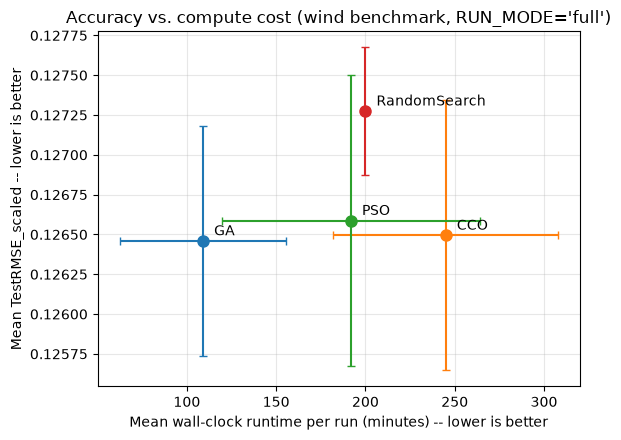


Saved figure -> {RESULTS_DIR / 'efficiency_pareto.png'}


In [16]:
# --- Efficiency analysis: accuracy vs. compute cost -------------------------------------
eff = wind_results_df.groupby("Algorithm").agg(
    MeanTestRMSE_scaled=("TestRMSE_scaled", "mean"),
    StdTestRMSE_scaled=("TestRMSE_scaled", "std"),
    MeanRuntimeSeconds=("RuntimeSeconds", "mean"),
    StdRuntimeSeconds=("RuntimeSeconds", "std"),
).reset_index()
eff["MeanRuntimeMin"] = eff["MeanRuntimeSeconds"] / 60
fastest_time = eff["MeanRuntimeSeconds"].min()
eff["RuntimeVsFastest_x"] = eff["MeanRuntimeSeconds"] / fastest_time
eff = eff.sort_values("MeanTestRMSE_scaled")

print("=" * 90)
print("EFFICIENCY: accuracy (TestRMSE_scaled) vs. compute cost (RuntimeSeconds), per algorithm")
print("=" * 90)
for _, r in eff.iterrows():
    std_str = f"+/- {r['StdTestRMSE_scaled']:.5f}" if pd.notna(r["StdTestRMSE_scaled"]) else "(single seed)"
    print(f"  {r['Algorithm']:12s} RMSE {r['MeanTestRMSE_scaled']:.5f} {std_str:16s} "
          f"runtime {r['MeanRuntimeMin']:7.1f} min  ({r['RuntimeVsFastest_x']:.2f}x the fastest)")

# Pareto front: an algorithm is dominated if another is at least as good on BOTH axes and
# strictly better on at least one (lower RMSE, lower runtime -- both "lower is better").
def _is_dominated(row, others):
    for _, o in others.iterrows():
        if o["Algorithm"] == row["Algorithm"]:
            continue
        not_worse = (o["MeanTestRMSE_scaled"] <= row["MeanTestRMSE_scaled"] and
                      o["MeanRuntimeSeconds"] <= row["MeanRuntimeSeconds"])
        strictly_better = (o["MeanTestRMSE_scaled"] < row["MeanTestRMSE_scaled"] or
                            o["MeanRuntimeSeconds"] < row["MeanRuntimeSeconds"])
        if not_worse and strictly_better:
            return True
    return False

eff["ParetoEfficient"] = ~eff.apply(lambda r: _is_dominated(r, eff), axis=1)
print()
print("Pareto-efficient (nothing else is at least as accurate AND at least as fast):")
print("  " + ", ".join(eff.loc[eff["ParetoEfficient"], "Algorithm"]))
_dominated = eff.loc[~eff["ParetoEfficient"], "Algorithm"].tolist()
if _dominated:
    print("Dominated (worse or equal on BOTH accuracy and speed vs. something else -- hard to justify using):")
    print("  " + ", ".join(_dominated))

display(eff[["Algorithm", "MeanTestRMSE_scaled", "StdTestRMSE_scaled", "MeanRuntimeMin",
             "RuntimeVsFastest_x", "ParetoEfficient"]])

# Pareto scatter for the paper: accuracy vs. cost, one point per algorithm.
fig, ax = plt.subplots(figsize=(6, 4.5))
for _, r in eff.iterrows():
    yerr = r["StdTestRMSE_scaled"] if pd.notna(r["StdTestRMSE_scaled"]) else 0
    xerr = r["StdRuntimeSeconds"] / 60 if pd.notna(r["StdRuntimeSeconds"]) else 0
    ax.errorbar(r["MeanRuntimeMin"], r["MeanTestRMSE_scaled"], xerr=xerr, yerr=yerr,
                fmt="o", capsize=3, markersize=8)
    ax.annotate(r["Algorithm"], (r["MeanRuntimeMin"], r["MeanTestRMSE_scaled"]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel("Mean wall-clock runtime per run (minutes) -- lower is better")
ax.set_ylabel("Mean TestRMSE_scaled -- lower is better")
ax.set_title(f"Accuracy vs. compute cost (wind benchmark, RUN_MODE={RUN_MODE!r})")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "efficiency_pareto.png", dpi=150)
plt.show()
print(f"\nSaved figure -> {{RESULTS_DIR / 'efficiency_pareto.png'}}")
